# Dimensionality Reduction for Clustering Visualization

**Goal:** Use PCA, t-SNE, and UMAP to visualize clusters in high-dimensional data, and understand their limits.

**Why it matters:**
- Real data is high-dimensional (10–1000+ features). Humans see 2D/3D. Reduction bridges that gap.
- You **cannot** trust clustering metrics alone — you must SEE the clusters.
- Each method has a distinct purpose; picking the wrong one lies to you.

**Prerequisite:** [01-kmeans-hierarchical-dbscan.ipynb](./01-kmeans-hierarchical-dbscan.ipynb)

**Datasets:**
- Digits (64 dims) — visual 2D structure
- Mall customers (2 dims) — sanity check

---

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, adjusted_rand_score

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
np.random.seed(42)

print("Setup complete.")

Setup complete.


## Why Reduce Dimensions?

**Three reasons:**

1. **Visualization** — you can't plot 64D. Reduce to 2D to see structure.
2. **Noise removal** — low-variance directions are often noise. Drop them.
3. **Speed** — K-Means on 2D runs 30× faster than on 64D, with similar quality.

**⚠️ The critical trap:**  
Reduction **changes distances**. Two points far apart in 64D may be close in 2D — or vice versa.  
A clustering that looks clean in 2D may be messy in high-D. **Never trust a 2D projection as ground truth.**

**Rule:** Use reduction for *exploration and presentation*, not for *deciding* whether clusters are real. Validate with metrics on the original data.

---

Shape: (1797, 64)
Classes: [0 1 2 3 4 5 6 7 8 9]
Feature range: [0.0, 16.0]


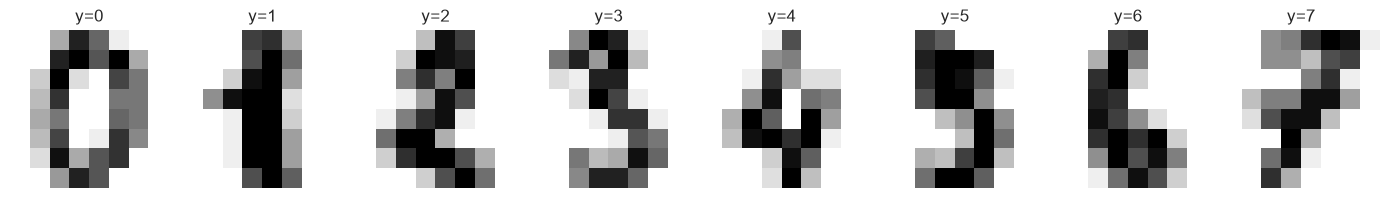

In [27]:
digits = load_digits()
X = digits.data      
y = digits.target    

print(f"Shape: {X.shape}")
print(f"Classes: {np.unique(y)}")
print(f"Feature range: [{X.min()}, {X.max()}]")

X_scaled = StandardScaler().fit_transform(X)

fig, axes = plt.subplots(1, 8, figsize=(14, 2.5))
for ax, i in zip(axes, range(8)):
    ax.imshow(X[i].reshape(8, 8), cmap="gray_r")
    ax.set_title(f"y={y[i]}")
    ax.axis("off")
plt.tight_layout()
plt.show()

0.21594970500832794
  PC1: 0.120
  PC2: 0.096


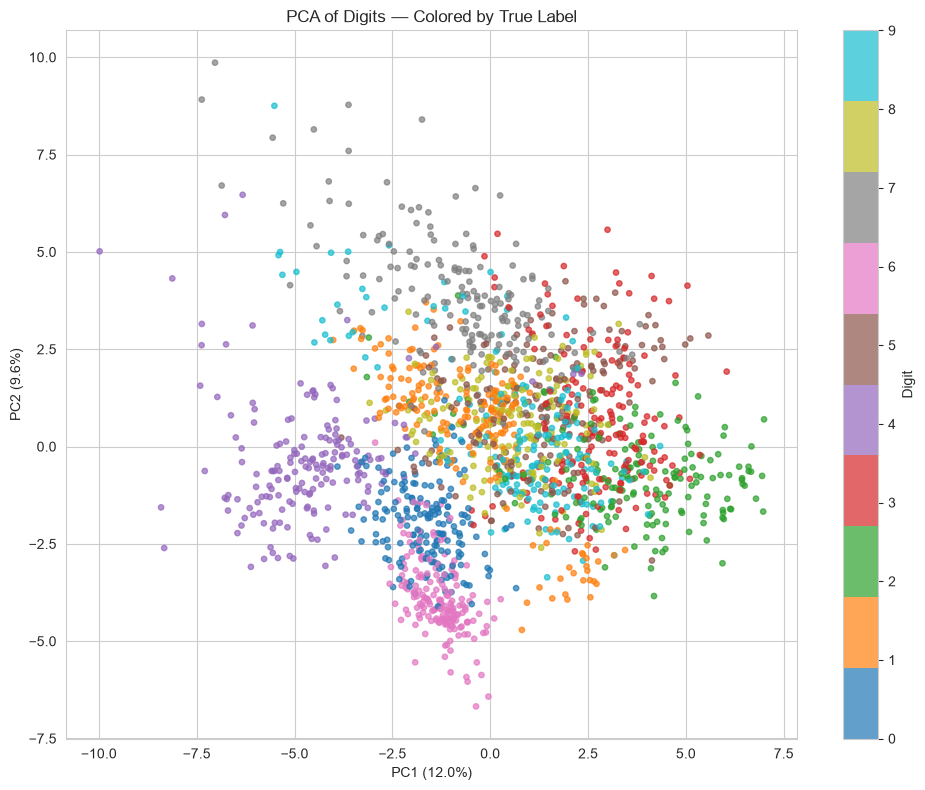

In [28]:
pca = PCA(
  n_components=2,
  random_state=42,
)

X_pca = pca.fit_transform(X_scaled)

print( pca.explained_variance_ratio_.sum())
print(f"  PC1: {pca.explained_variance_ratio_[0]:.3f}")
print(f"  PC2: {pca.explained_variance_ratio_[1]:.3f}")

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap="tab10", alpha=0.7, s=15)
plt.colorbar(scatter, label="Digit")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("PCA of Digits — Colored by True Label")
plt.tight_layout()
plt.show()

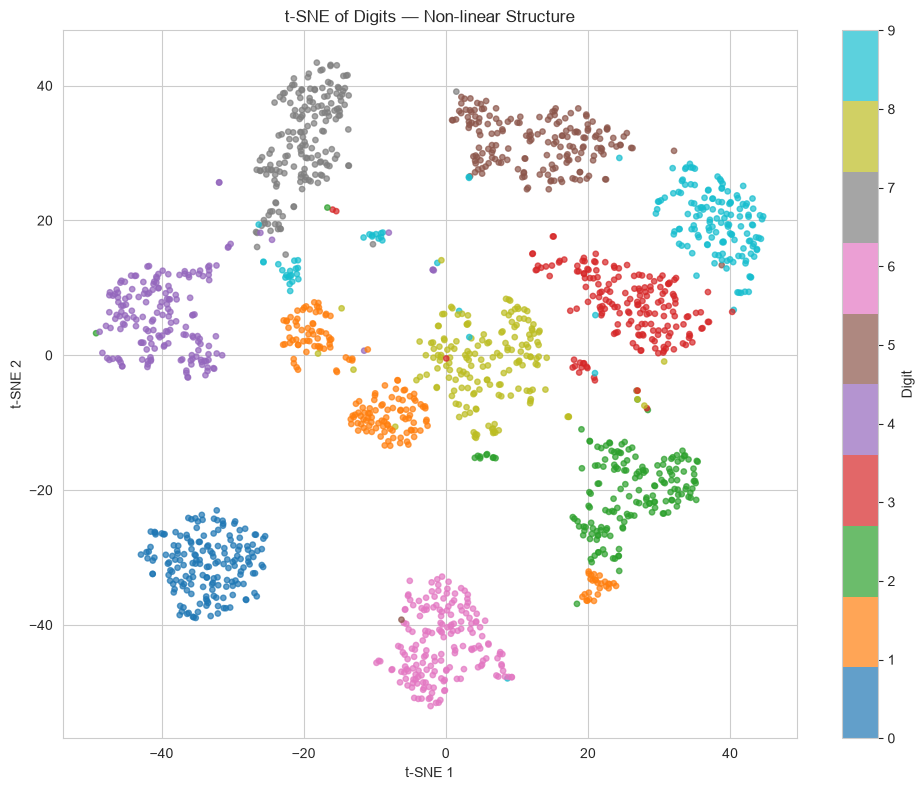

In [29]:
tsne = TSNE(
    n_components=2,
    
    perplexity=30,
    
    init="pca",

    # n_iter=500,
    
    random_state=42,

)

X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap="tab10", alpha=0.7, s=15)
plt.colorbar(scatter, label="Digit")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE of Digits — Non-linear Structure")
plt.tight_layout()
plt.show()

## ⚠️ Critical Warnings About t-SNE

1. **Distances between clusters are MEANINGLESS.**  
   A "gap" of 10 units vs 3 units has no quantitative meaning.
   Only **grouping** is informative.

2. **Cluster sizes are NOT meaningful.**  
   Dense clusters can appear small; spread clusters can appear large.
   This is an artifact of the algorithm.

3. **Density is NOT preserved.**  
   Don't interpret "this region looks denser" as real density.

4. **Random state changes everything.**  
   Different seeds → different plots. The structure is similar, but positions aren't.

5. **t-SNE is for visualization only.**  
   Never use its output as model features. PCA output IS usable as features.

**Golden rule:** t-SNE tells you "is there structure?" It does NOT tell you "how much structure" or "how far apart."

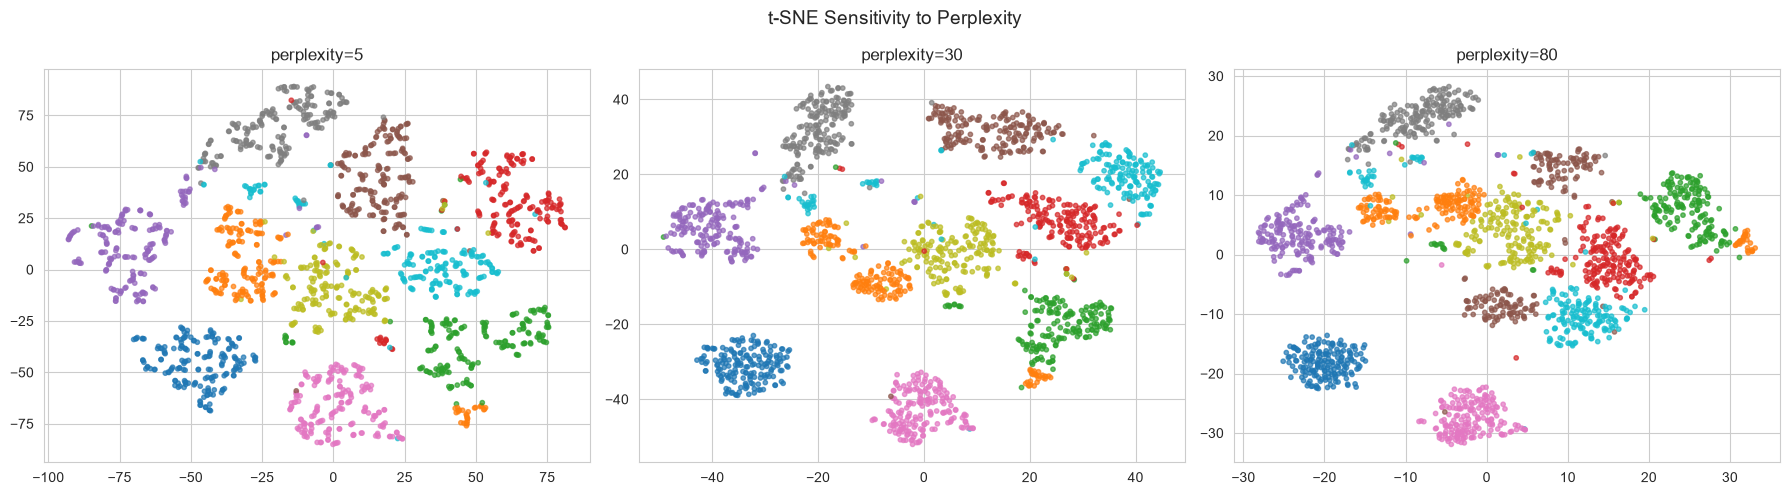

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, perp in zip(axes, [5, 30, 80]):
    ts = TSNE(n_components=2, perplexity=perp, init="pca",
              learning_rate="auto", random_state=42, n_jobs=-1)
    emb = ts.fit_transform(X_scaled)
    ax.scatter(emb[:, 0], emb[:, 1], c=y, cmap="tab10", alpha=0.7, s=10)
    ax.set_title(f"perplexity={perp}")

plt.suptitle("t-SNE Sensitivity to Perplexity", fontsize=14)
plt.tight_layout()
plt.show()

In [37]:
km_raw = KMeans(n_clusters=10, n_init=10, random_state=42)
labels_raw = km_raw.fit_predict(X_scaled)

pca_20 = PCA(n_components=20, random_state=42)
X_pca20 = pca_20.fit_transform(X_scaled)
km_pca = KMeans(n_clusters=10, n_init=10, random_state=42)  # n_jobs حذف شد
labels_pca = km_pca.fit_predict(X_pca20)

ari_raw = adjusted_rand_score(y, labels_raw)
ari_pca = adjusted_rand_score(y, labels_pca)

print(f"K-Means on raw 64D → ARI: {ari_raw:.3f}")
print(f"K-Means on PCA 20D → ARI: {ari_pca:.3f}")
print(f"Variance kept: {pca_20.explained_variance_ratio_.sum():.3f}")

K-Means on raw 64D → ARI: 0.534
K-Means on PCA 20D → ARI: 0.397
Variance kept: 0.793


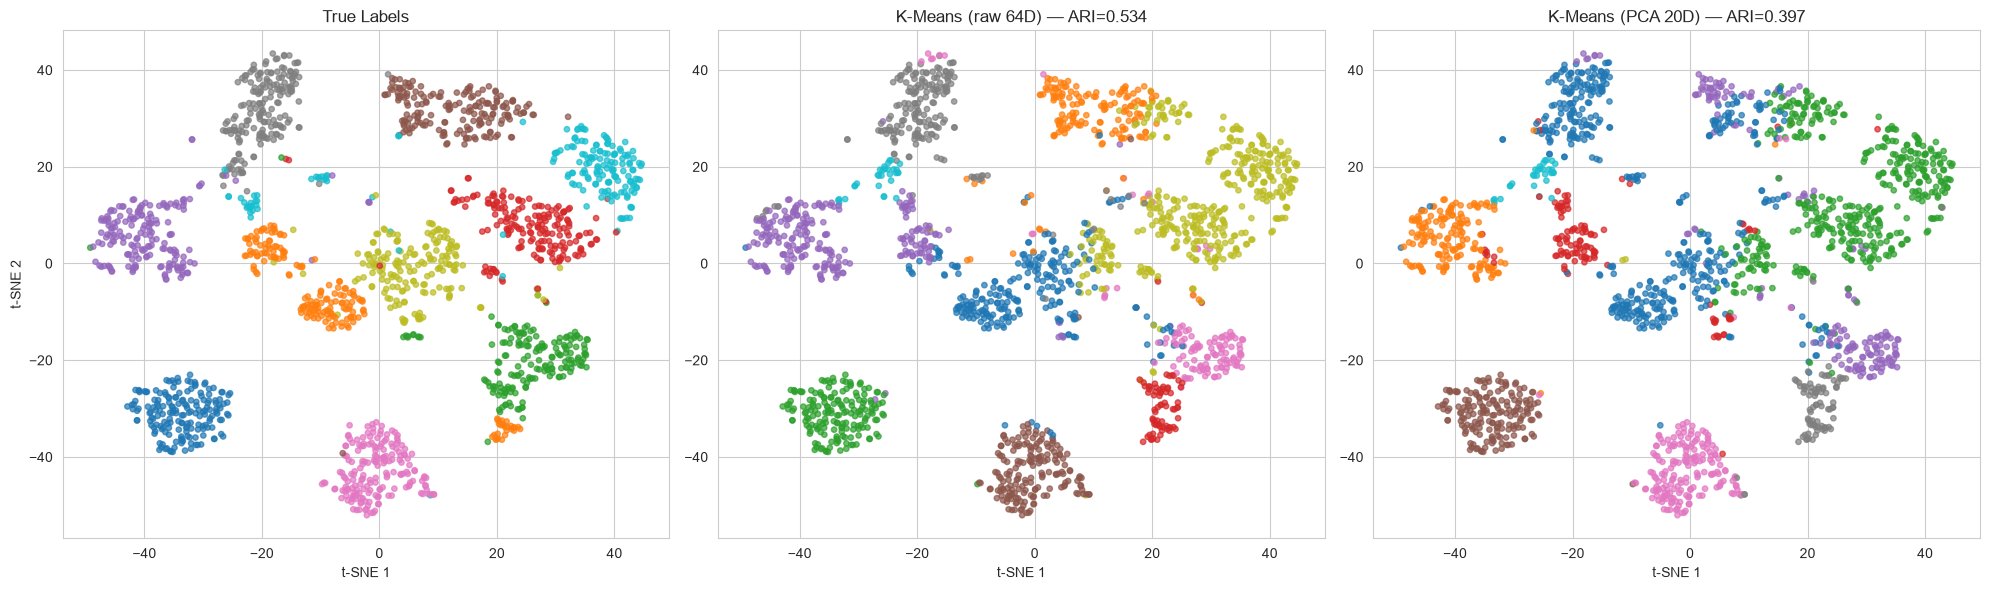

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# True labels (for reference)
axes[0].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap="tab10", alpha=0.7, s=15)
axes[0].set_title("True Labels")
axes[0].set_xlabel("t-SNE 1"); axes[0].set_ylabel("t-SNE 2")

# K-Means on raw
axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels_raw, cmap="tab10", alpha=0.7, s=15)
axes[1].set_title(f"K-Means (raw 64D) — ARI={ari_raw:.3f}")
axes[1].set_xlabel("t-SNE 1")

# K-Means on PCA
axes[2].scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels_pca, cmap="tab10", alpha=0.7, s=15)
axes[2].set_title(f"K-Means (PCA 20D) — ARI={ari_pca:.3f}")
axes[2].set_xlabel("t-SNE 1")

plt.tight_layout()
plt.show()

Variance explained (PC1+PC2): 0.776


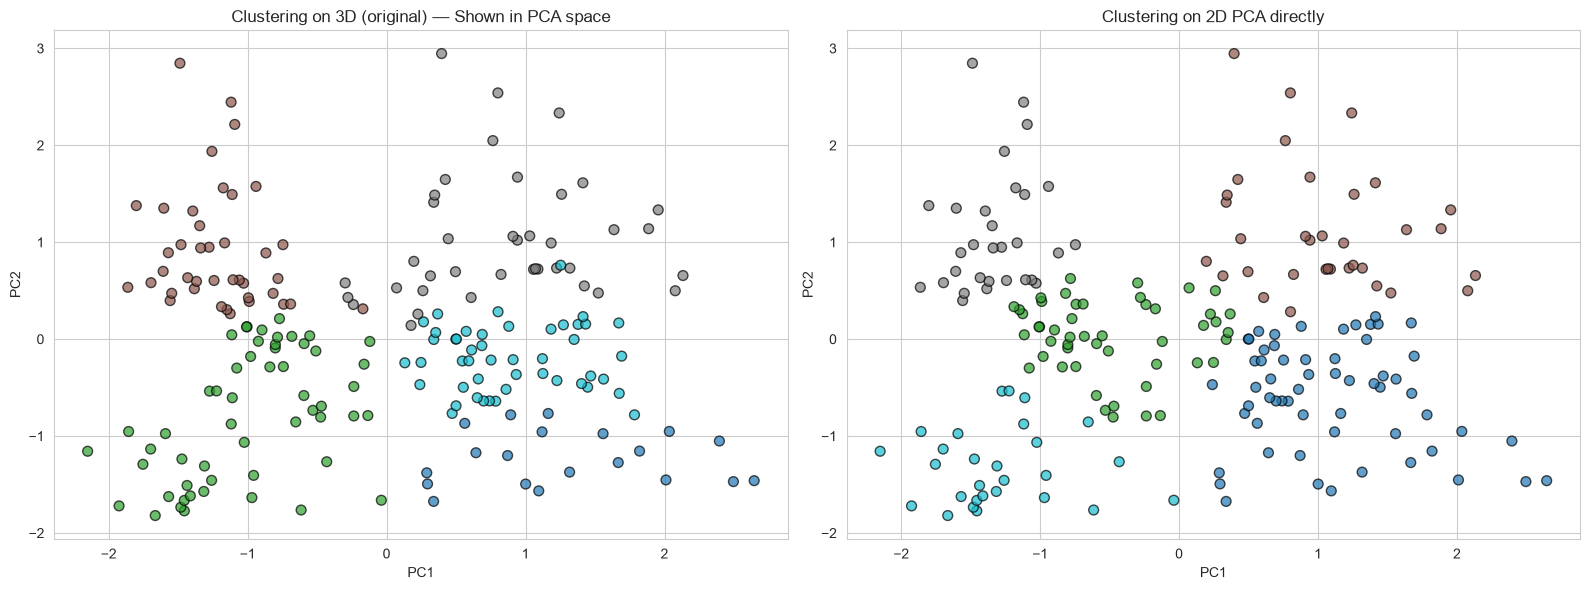

ARI between 3D and 2D clustering: 0.522


In [39]:
url = "https://raw.githubusercontent.com/tirthajyoti/Machine-Learning-with-Python/master/Datasets/Mall_Customers.csv"

df = pd.read_csv(url)

# Use more features than before (not just 2)
features = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]
X_mall = df[features].copy()
X_mall_scaled = StandardScaler().fit_transform(X_mall)

# PCA to 2D
pca_mall = PCA(n_components=2, random_state=42)
X_mall_pca = pca_mall.fit_transform(X_mall_scaled)

print(f"Variance explained (PC1+PC2): {pca_mall.explained_variance_ratio_.sum():.3f}")

# K-Means on 3D original
km_mall = KMeans(n_clusters=5, n_init=10, random_state=42)
df["Cluster_3D"] = km_mall.fit_predict(X_mall_scaled)

# K-Means on 2D PCA
km_mall_2d = KMeans(n_clusters=5, n_init=10, random_state=42)
df["Cluster_2D"] = km_mall_2d.fit_predict(X_mall_pca)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 3D-based clustering projected to PCA space
axes[0].scatter(X_mall_pca[:, 0], X_mall_pca[:, 1], c=df["Cluster_3D"],
                cmap="tab10", alpha=0.7, s=50, edgecolor="k")
axes[0].set_title("Clustering on 3D (original) — Shown in PCA space")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")

# 2D-based clustering
axes[1].scatter(X_mall_pca[:, 0], X_mall_pca[:, 1], c=df["Cluster_2D"],
                cmap="tab10", alpha=0.7, s=50, edgecolor="k")
axes[1].set_title("Clustering on 2D PCA directly")
axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2")

plt.tight_layout()
plt.show()

# Do the two agree?
ari_mall = adjusted_rand_score(df["Cluster_3D"], df["Cluster_2D"])
print(f"ARI between 3D and 2D clustering: {ari_mall:.3f}")

## Choosing a Reduction Method — Cheat Sheet

| Goal | Method |
|------|--------|
| Speed up downstream model | **PCA** |
| Visualize clusters | **t-SNE** (or UMAP) |
| Preserve global structure | **PCA** |
| Preserve local neighborhoods | **t-SNE**, UMAP |
| Reduce noise | **PCA** |
| Non-linear manifold | **t-SNE**, UMAP, autoencoders |
| Need deterministic output | **PCA** |
| Data > 10K samples | **PCA** (t-SNE is slow) |

### Recommended Workflow

1. **First look:** PCA — quick, deterministic, shows linear structure
2. **If non-linear suspected:** t-SNE with multiple perplexities
3. **Compare:** Do clusterings agree in both spaces? (ARI)
4. **Validate:** clustering metrics on ORIGINAL data, not reduced

### UMAP (brief)

- Successor to t-SNE. Faster, preserves global structure better.
- Library: `pip install umap-learn`
- API is identical to sklearn's.
- **Preferred for production use** over t-SNE when available.

---

In [40]:
# Critical: are the metrics consistent between spaces?
# Compare silhouette on raw vs PCA on the SAME K-Means labels

sil_raw = silhouette_score(X_scaled, labels_raw)
sil_pca = silhouette_score(X_pca20, labels_pca)

print(f"Silhouette (original 64D): {sil_raw:.4f}")
print(f"Silhouette (PCA 20D)     : {sil_pca:.4f}")
print(f"Difference               : {abs(sil_raw - sil_pca):.4f}")

Silhouette (original 64D): 0.1394
Silhouette (PCA 20D)     : 0.1960
Difference               : 0.0566


## Summary

### Key ideas

- **PCA** — linear, fast, deterministic. Good for compression and speed. Output IS usable as features.
- **t-SNE** — non-linear, slow, stochastic. Good for visualization only. Output is NOT usable as features.
- **UMAP** — modern alternative to t-SNE. Fast + non-linear + global structure preserved.

### Critical rules

1. **Always scale before reduction.** Unscaled features distort distances.
2. **Never trust a 2D plot as ground truth.** Validate with metrics on original data.
3. **t-SNE distances are meaningless.** Only grouping is informative.
4. **Multiple perplexities for t-SNE.** Report which you chose and why.
5. **Clustering metrics on ORIGINAL data.** Reduction is for exploration, not evaluation.

### The workflow we used

1. Loaded high-dim data (64D digits)
2. PCA → saw limited structure
3. t-SNE → clear digit separation
4. K-Means on raw vs PCA → compared with ARI
5. Validated metric consistency between spaces

## 🚀 Next

→ [mini-project/customer-segmentation.ipynb](./mini-project/customer-segmentation.ipynb): apply everything to a real business problem.

Or move to the next section:

→ [../05-model-evaluation/01-overfitting-underfitting.ipynb](../05-model-evaluation/01-overfitting-underfitting.ipynb)